In [63]:
import pandas as pd
import numpy as np
from scipy.stats import norm, lognorm, gamma, weibull_min

import matplotlib.pyplot as plt

In [64]:
precip = pd.read_csv("/workspaces/AnaliticaDeDatos/datos/clases/clase_3_probabilidad_e_inferencia/rainAEMET005_24h_1981-2022_promedio_Anllons.csv", sep=";", decimal=".")
precip['Date'] = pd.to_datetime(precip['Date'], format="%d/%m/%Y %H:%M")
precip['Date'] = precip['Date'].dt.normalize()
precip = precip.set_index('Date')
precip.index.name = 'time'

Vamos a trabajar ahora con datos reales de precipitación diaria.

Antes de intentar ajustar una distribución, debemos explorar cómo son nuestros datos.

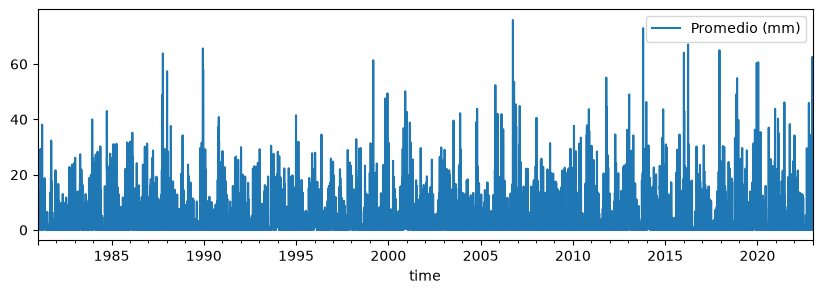

In [65]:
fig, ax = plt.subplots(figsize=(10,3))
precip.plot(ax=ax)

plt.show()

In [66]:
precip_2000 = precip[precip.index.year == 2000]

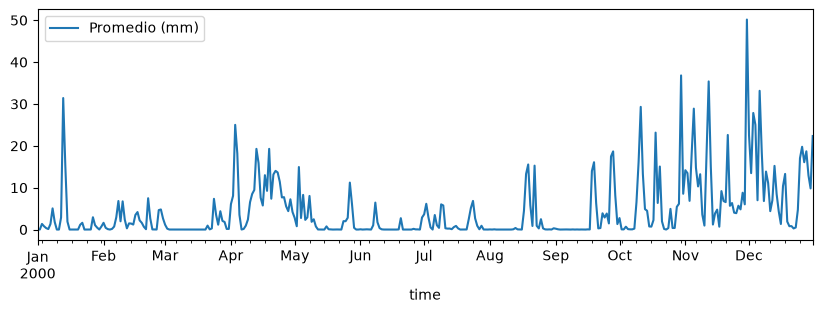

In [67]:
fig, ax = plt.subplots(figsize=(10,3))
precip_2000.plot(ax=ax)

plt.show()

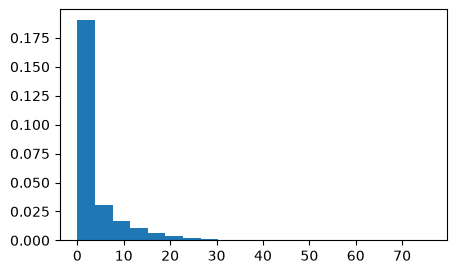

In [68]:
fig, ax = plt.subplots(figsize=(5,3))
ax.hist(precip, bins=20, density=True)

plt.show()

Una característica importante de la precipitación es la presencia de muchos valores iguales a cero: hay días en los que simplemente no llueve.

Esto plantea una cuestión importante: las distribuciones continuas que hemos visto describen valores positivos, pero no pueden asignar una probabilidad concreta a $X=0$.

Por tanto, podemos pensar en la precipitación como dos procesos:

¿Llueve o no llueve?
Si llueve, ¿cuánta precipitación cae?

Para empezar, vamos a separar los días sin precipitación de los días con precipitación y estudiar únicamente los valores positivos.

In [69]:
precip_positiva = precip[precip > 0]
precip_positiva = precip_positiva.dropna()

(array([1.05114418e-01, 1.72043982e-02, 6.09896978e-03, 1.97288414e-03,
        7.31876374e-04, 3.07600215e-04, 1.16675944e-04, 7.42483278e-05,
        8.48552318e-05, 2.12138079e-05]),
 array([5.000000e-04, 7.591950e+00, 1.518340e+01, 2.277485e+01,
        3.036630e+01, 3.795775e+01, 4.554920e+01, 5.314065e+01,
        6.073210e+01, 6.832355e+01, 7.591500e+01]),
 <BarContainer object of 10 artists>)

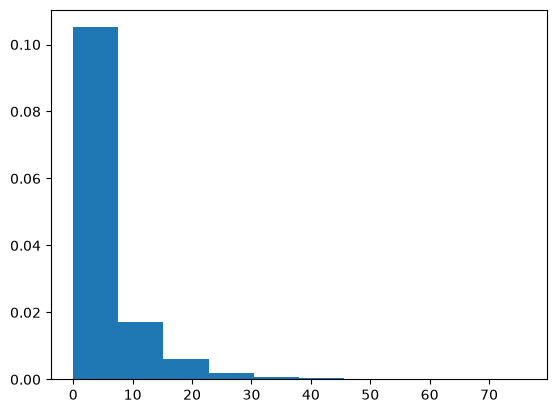

In [70]:
plt.hist(precip_positiva, density=True)

#### Vamos a probar a ajustar a varias distribuciones

In [71]:
from scipy.stats import norm

# Ajustamos una distribución normal
parametros = norm.fit(precip_positiva)

print(parametros) #Sabemos que son la media y la desviación, pero si no tendreís que ir a la documentación de scipy a ver que parametros tiene.

(np.float64(4.406151380948547), np.float64(6.777251096658608))


In [72]:
media, desviacion = norm.fit(precip_positiva)

print("Media:", media)
print("Desviación estándar:", desviacion)

Media: 4.406151380948547
Desviación estándar: 6.777251096658608


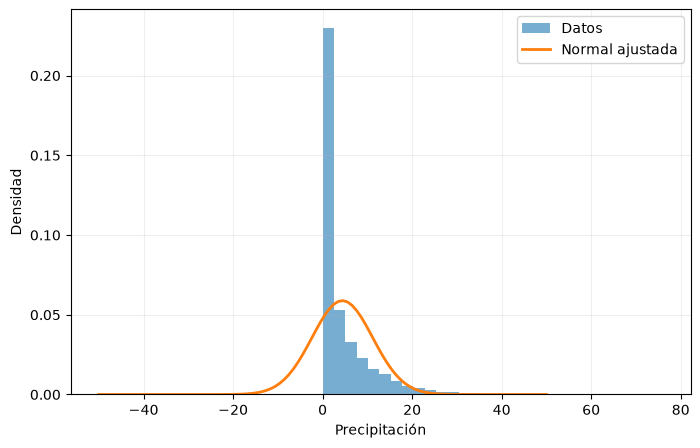

In [73]:
x = np.linspace(
    -50,
    50,
    100
)

pdf = norm.pdf(
    x,
    loc=media,
    scale=desviacion
)

plt.figure(figsize=(8, 5))

plt.hist(
    precip_positiva,
    bins=30,
    density=True,
    alpha=0.6,
    label="Datos"
)

plt.plot(
    x,
    pdf,
    linewidth=2,
    label="Normal ajustada"
)

plt.xlabel("Precipitación")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

El histograma nos permite comparar visualmente los datos con la distribución ajustada. Sin embargo, podemos utilizar otra herramienta para comprobar de forma más sistemática si nuestros datos son compatibles con una determinada distribución: el **QQ-plot** (*Quantile-Quantile plot*).

La idea es comparar los **cuantiles de nuestros datos** con los cuantiles que esperaríamos obtener si los datos siguieran la distribución que estamos estudiando.

Si la distribución describe bien nuestros datos, los puntos deberían situarse aproximadamente sobre una línea recta.

Vamos a comprobarlo para la distribución normal que acabamos de ajustar.


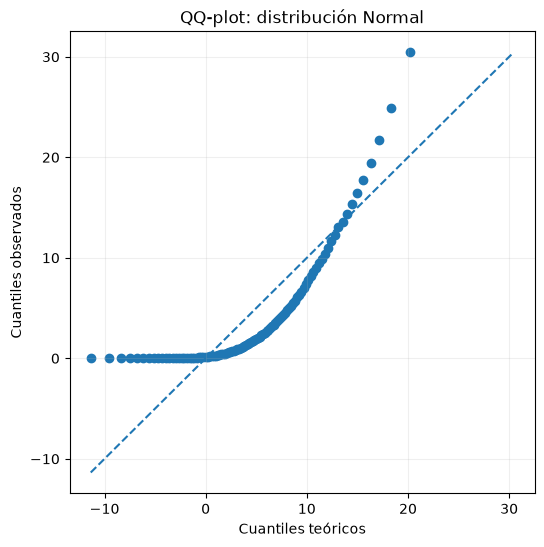

In [74]:
# Cuantiles que queremos comparar
q = np.linspace(0.01, 0.99, 100)

# Cuantiles de los datos
cuantiles_datos = np.quantile(precip_positiva, q)

# Cuantiles teóricos de la Normal ajustada
cuantiles_teoricos = norm.ppf(
    q,
    loc=media,
    scale=desviacion
)

# QQ-plot
plt.figure(figsize=(6, 6))

plt.scatter(
    cuantiles_teoricos,
    cuantiles_datos
)

# Línea de referencia
minimo = min(cuantiles_teoricos.min(), cuantiles_datos.min())
maximo = max(cuantiles_teoricos.max(), cuantiles_datos.max())

plt.plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

plt.xlabel("Cuantiles teóricos")
plt.ylabel("Cuantiles observados")
plt.title("QQ-plot: distribución Normal")

plt.grid(alpha=0.2)
plt.show()

Este ajuste no es nada bueno. La distribución Normal, además de permitir valores negativos, no reproduce bien la forma de nuestros datos.

Vamos a probar ahora con otras distribuciones que pueden ser más adecuadas para variables positivas y asimétricas:

- Lognormal
- Gamma
- Weibull

Ajustaremos cada una de ellas a nuestros datos y compararemos visualmente las distribuciones obtenidas con el histograma.

Shape: 2.6664034799492153
Loc: 0.00033710427390069766
Scale: 0.7331166086240956


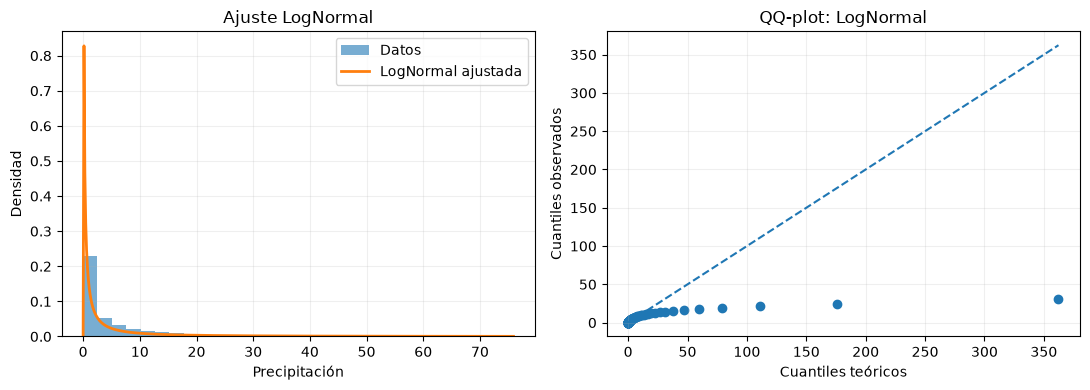

In [75]:
from scipy.stats import lognorm

# Ajustamos la distribución Lognormal
shape, loc, scale = lognorm.fit(precip_positiva)

print("Shape:", shape)
print("Loc:", loc)
print("Scale:", scale)

# Valores para representar la PDF
x = np.linspace(0, precip_positiva.max(), 500)

pdf = lognorm.pdf(
    x,
    shape,
    loc=loc,
    scale=scale
)

# QQ-plot
q = np.linspace(0.01, 0.99, 100)

cuantiles_datos = np.quantile(precip_positiva, q)

cuantiles_teoricos = lognorm.ppf(
    q,
    shape,
    loc=loc,
    scale=scale
)

# Figura
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histograma + PDF
axes[0].hist(
    precip_positiva,
    bins=30,
    density=True,
    alpha=0.6,
    label="Datos"
)

axes[0].plot(
    x,
    pdf,
    linewidth=2,
    label="LogNormal ajustada"
)

axes[0].set_xlabel("Precipitación")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Ajuste LogNormal")
axes[0].legend()
axes[0].grid(alpha=0.2)

# QQ-plot
axes[1].scatter(
    cuantiles_teoricos,
    cuantiles_datos
)

minimo = min(cuantiles_teoricos.min(), cuantiles_datos.min())
maximo = max(cuantiles_teoricos.max(), cuantiles_datos.max())

axes[1].plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

axes[1].set_xlabel("Cuantiles teóricos")
axes[1].set_ylabel("Cuantiles observados")
axes[1].set_title("QQ-plot: LogNormal")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [76]:
from scipy.stats import gamma

# Ajustamos la distribución Gamma
shape, loc, scale = gamma.fit(precip_positiva)

print("Shape:", shape)
print("Loc:", loc)
print("Scale:", scale)

Shape: 0.41876594932215944
Loc: 0.0004999999999999999
Scale: 9.813996810592624


Shape: 0.41876594932215944
Loc: 0.0004999999999999999
Scale: 9.813996810592624


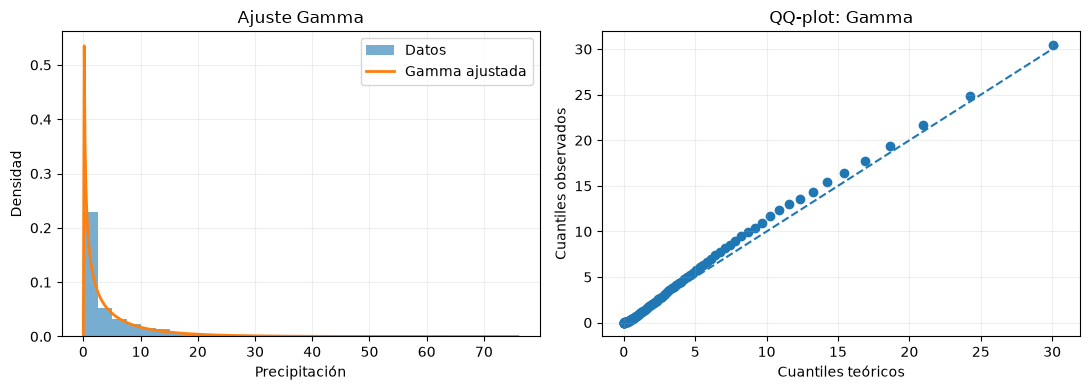

In [77]:
from scipy.stats import gamma

# Ajustamos la distribución Gamma
shape, loc, scale = gamma.fit(precip_positiva)

print("Shape:", shape)
print("Loc:", loc)
print("Scale:", scale)

# Valores para representar la PDF
x = np.linspace(0, precip_positiva.max(), 500)

pdf = gamma.pdf(
    x,
    shape,
    loc=loc,
    scale=scale
)

# Cuantiles para el QQ-plot
q = np.linspace(0.01, 0.99, 100)

cuantiles_datos = np.quantile(precip_positiva, q)

cuantiles_teoricos = gamma.ppf(
    q,
    shape,
    loc=loc,
    scale=scale
)

# Figura
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histograma + PDF
axes[0].hist(
    precip_positiva,
    bins=30,
    density=True,
    alpha=0.6,
    label="Datos"
)

axes[0].plot(
    x,
    pdf,
    linewidth=2,
    label="Gamma ajustada"
)

axes[0].set_xlabel("Precipitación")
axes[0].set_ylabel("Densidad")
axes[0].set_title("Ajuste Gamma")
axes[0].legend()
axes[0].grid(alpha=0.2)

# QQ-plot
axes[1].scatter(
    cuantiles_teoricos,
    cuantiles_datos
)

minimo = min(
    cuantiles_teoricos.min(),
    cuantiles_datos.min()
)

maximo = max(
    cuantiles_teoricos.max(),
    cuantiles_datos.max()
)

axes[1].plot(
    [minimo, maximo],
    [minimo, maximo],
    linestyle="--"
)

axes[1].set_xlabel("Cuantiles teóricos")
axes[1].set_ylabel("Cuantiles observados")
axes[1].set_title("QQ-plot: Gamma")
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

Hasta ahora hemos analizado los días en los que se produce precipitación, pero ¿qué ocurre con los días en los que no llueve?

Podemos separar el problema en dos partes. Por un lado, podemos estudiar el proceso llueve o no llueve mediante una variable de Bernoulli. Por otro, cuando llueve, podemos estudiar la cantidad de precipitación mediante una distribución continua, como hemos hecho anteriormente.

Definimos entonces una variable que tome el valor $1$ cuando llueve y $1$ cuando no llueve.

In [78]:
precip

,Promedio (mm)
time,
1981-01-01,0.0090
1981-01-02,0.0000
1981-01-03,0.0010
1981-01-04,0.9195
1981-01-05,0.0005
...,...
2022-12-26,0.1050
2022-12-27,0.4600
2022-12-28,6.3100


In [79]:
# Creamos una variable Bernoulli:
# 1 = llueve, 0 = no llueve

precip["Bernoulli"] = (precip["Promedio (mm)"] > 0).astype(int)

precip.head()

,Promedio (mm),Bernoulli
time,,
1981-01-01,0.0090,1
1981-01-02,0.0000,0
1981-01-03,0.0010,1
1981-01-04,0.9195,1
1981-01-05,0.0005,1


In [80]:
precip

,Promedio (mm),Bernoulli
time,,
1981-01-01,0.0090,1
1981-01-02,0.0000,0
1981-01-03,0.0010,1
1981-01-04,0.9195,1
1981-01-05,0.0005,1
...,...,...
2022-12-26,0.1050,1
2022-12-27,0.4600,1
2022-12-28,6.3100,1


In [81]:
p_lluvia = precip["Bernoulli"].mean()

print(f"Probabilidad estimada de lluvia: {p_lluvia:.2%}")

Probabilidad estimada de lluvia: 80.96%


In [82]:
print(precip["Bernoulli"].value_counts())

Bernoulli
1    12419
0     2920
Name: count, dtype: int64


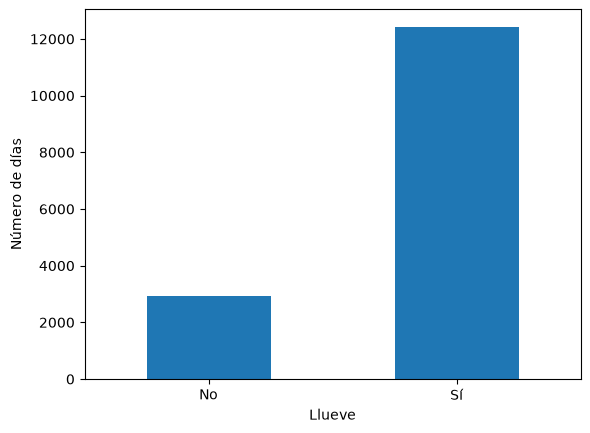

In [83]:
precip["Bernoulli"].value_counts().sort_index().plot(
    kind="bar",
    rot=0,
)

plt.xlabel("Llueve")
plt.ylabel("Número de días")
plt.xticks([0, 1], ["No", "Sí"])
plt.show()

In [84]:
# Extraemos el mes
precip["mes"] = precip.index.month

precip.head()

,Promedio (mm),Bernoulli,mes
time,,,
1981-01-01,0.0090,1,1
1981-01-02,0.0000,0,1
1981-01-03,0.0010,1,1
1981-01-04,0.9195,1,1
1981-01-05,0.0005,1,1


In [85]:
probabilidad_lluvia = precip.groupby("mes")["Bernoulli"].mean()

print(probabilidad_lluvia)

mes
1     0.889401
2     0.823777
3     0.798771
4     0.820635
5     0.807220
6     0.756349
7     0.699693
8     0.723502
9     0.745238
10    0.851767
11    0.907143
12    0.893159
Name: Bernoulli, dtype: float64


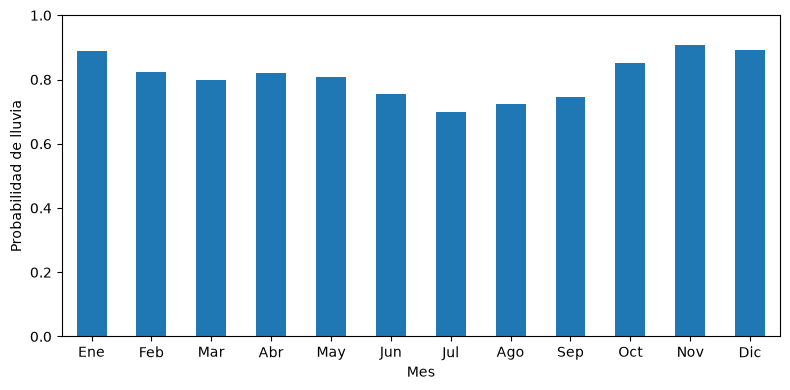

In [86]:
probabilidad_lluvia.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.xlabel("Mes")
plt.ylabel("Probabilidad de lluvia")
plt.xticks(
    range(12),
    ["Ene", "Feb", "Mar", "Abr", "May", "Jun",
     "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"],
    rotation=0
)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Ahora vamos a usar la distribución que hemos obtenido para responder a ciertas preguntas de ingeniería.

¿Cuál es la probabilidad de que, en un día de lluvia, la precipitación sea inferior a 10 mm?

In [92]:
# Ajustamos la distribución Gamma
shape_g, loc_g, scale_g = gamma.fit(precip_positiva)

print("Shape:", shape_g)
print("Loc:", loc_g)
print("Scale:", scale_g)

Shape: 0.41876594932215944
Loc: 0.0004999999999999999
Scale: 9.813996810592624


In [93]:
from scipy.stats import gamma

probabilidad = gamma.cdf(
    10,
    shape_g,
    loc=loc_g,
    scale=scale_g
)

print(f"P(X ≤ 10 mm) = {probabilidad:.2%}")

P(X ≤ 10 mm) = 87.69%


¿Cuál es la probabilidad de que la precipitación esté entre 10 y 20 mm?

In [94]:
probabilidad = (
    gamma.cdf(20, shape_g, loc=loc_g, scale=scale_g)
    - gamma.cdf(10, shape_g, loc=loc_g, scale=scale_g)
)

print(f"P(10 < X ≤ 20 mm) = {probabilidad:.2%}")

P(10 < X ≤ 20 mm) = 8.96%


¿Cuál es la probabilidad de que un día de lluvia tenga más de 20 mm?

In [95]:
probabilidad = 1 - gamma.cdf(
    20,
    shape_g,
    loc=loc_g,
    scale=scale_g
)

print(f"P(X > 20 mm) = {probabilidad:.2%}")

P(X > 20 mm) = 3.35%
